In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#market data
df = pd.read_csv('odds_2022-2023_v2.csv')
df = df.drop('Unnamed: 0',axis=1)
#df['match id'] = df['Home Team']+'_'+df['Away Team']


In [3]:
#goals data
goals = pd.read_csv("goals_2022-2023.csv")
goals['Half Time'] = '0'
goals['Goal Scored'] = 'Yes'
goals['date'] = goals['date'].str[:10]

In [5]:
#list of matches
matches = df[['Home Team','Away Team']].drop_duplicates()
matches['match id'] = matches['Home Team']+'_'+matches['Away Team']
matches_list = matches['match id'].tolist()
zipped_matches = list(zip(matches['Home Team'],matches['Away Team']))
print(zipped_matches)

[('Crystal Palace', 'Arsenal'), ('Fulham', 'Liverpool'), ('Tottenham', 'Southampton'), ('Newcastle', 'Nottingham Forest'), ('Leicester', 'Brentford'), ('Leeds', 'Wolverhampton'), ('Bournemouth', 'Aston Villa'), ('Everton', 'Chelsea'), ('Manchester United', 'Brighton'), ('West Ham', 'Manchester City'), ('Wolverhampton', 'Fulham'), ('Southampton', 'Leeds'), ('Nottingham Forest', 'West Ham'), ('Manchester City', 'Bournemouth'), ('Liverpool', 'Crystal Palace'), ('Arsenal', 'Leicester'), ('Chelsea', 'Tottenham'), ('Brighton', 'Newcastle'), ('Brentford', 'Manchester United'), ('Aston Villa', 'Everton'), ('Tottenham', 'Wolverhampton'), ('Leicester', 'Southampton'), ('Fulham', 'Brentford'), ('Crystal Palace', 'Aston Villa'), ('West Ham', 'Brighton'), ('Newcastle', 'Manchester City'), ('Leeds', 'Chelsea'), ('Bournemouth', 'Arsenal'), ('Everton', 'Nottingham Forest'), ('Manchester United', 'Liverpool'), ('Southampton', 'Manchester United'), ('Chelsea', 'Leicester'), ('Manchester City', 'Crystal 

In [25]:
#function to create dataframe for a single match
def match_df(home,away,df):
    match_odds = df[(df['Home Team']==home)&(df['Away Team']==away)].copy()

    norm_mins = [(x,0,0) for x in range(0,91)]
    match_odds['time key'] = list(zip(match_odds['Elapsed Time'].astype(int),match_odds['Added Time'].astype(int),match_odds['Half Time'].astype(int)))
    extra_times = set(match_odds['time key'])-set(norm_mins)
    all_times = sorted(norm_mins+list(extra_times))
    new_df = pd.DataFrame(all_times,columns = ['Elapsed Time','Added Time','Half Time'])
    new_df['time key'] = list(zip(new_df['Elapsed Time'].astype(int),new_df['Added Time'].astype(int),new_df['Half Time'].astype(int)))

    
    under = match_odds[match_odds['Selection']=='Under 2.5 Goals'].copy()
    over = match_odds[match_odds['Selection']=='Over 2.5 Goals'].copy()
    exact_1_1 = match_odds[match_odds['Selection']=='1 - 1'].copy()
    exact_2_0 = match_odds[match_odds['Selection']=='2 - 0'].copy()
    exact_0_2 = match_odds[match_odds['Selection']=='0 - 2'].copy()
    exact_1_0 = match_odds[match_odds['Selection']=='1 - 0'].copy()
    exact_0_1 = match_odds[match_odds['Selection']=='0 - 1'].copy()
    exact_0_0 = match_odds[match_odds['Selection']=='0 - 0'].copy()

    markets = {'Under 2.5 Odds':under,'Over 2.5 Odds':over,'1-1 Odds':exact_1_1,'2-0 Odds':exact_2_0,'0-2 Odds':exact_0_2,'1-0 Odds':exact_1_0,'0-1 Odds':exact_0_1,'0-0 Odds':exact_0_0}
    for market in markets:
        new_df = new_df.merge(markets[market][['time key','Last Traded Price']],on='time key',how ='left')
        new_df = new_df.rename(columns={'Last Traded Price':market})
        still_live = new_df[market].notna() & (new_df[market]!= 1000)
        if still_live.any():
            last_live_idx = still_live[::-1].idxmax()
            new_df.loc[last_live_idx+1:,market]= 1000
        new_df[market]=new_df[market].ffill()
        new_df[market]=new_df[market].bfill()

    new_df['Synthetic']=1/(1/new_df['1-1 Odds']+1/new_df['2-0 Odds']+1/new_df['0-2 Odds']+1/new_df['1-0 Odds']+1/new_df['0-1 Odds']+1/new_df['0-0 Odds'])
    goals2 = goals[(goals['Home Team']==home)&(goals['Away Team']==away)].copy()
    goals2['time key'] = list(zip(goals2['Elapsed Time'].astype(int),goals2['Added Time'].astype(int),goals2['Half Time'].astype(int)))

    new_df = new_df.merge(goals2[['time key','Goal Scored','Player','Goal Type','Score']],on='time key',how ='left')
    new_df['Score']=new_df['Score'].ffill()
    new_df['Score']=new_df['Score'].fillna('0-0')
    new_df['Goal Scored']=new_df['Goal Scored'].fillna('No')

    def format_time(row):
        if row['Half Time']>0:
            return f'HT{row['Half Time']}'
        elif row['Added Time']>0:
            return f"{row['Elapsed Time']}+{row['Added Time']}"
        else: 
            return f"{row['Elapsed Time']}"

    new_df['plot label'] = new_df.apply(format_time,axis=1)
    df_lite = new_df[['time key','Under 2.5 Odds', 'Synthetic','Goal Scored','Score','plot label']]
    return df_lite
match_df('Manchester City','Southampton',df).head()

,time key,Under 2.5 Odds,Synthetic,Goal Scored,Score,plot label
0,"(0, 0, 0)",4.5,5.121827,No,0-0,0
1,"(1, 0, 0)",4.5,5.121827,No,0-0,1
2,"(2, 0, 0)",4.3,4.627998,No,0-0,2
3,"(3, 0, 0)",4.4,4.702991,No,0-0,3
4,"(4, 0, 0)",4.2,4.576162,No,0-0,4


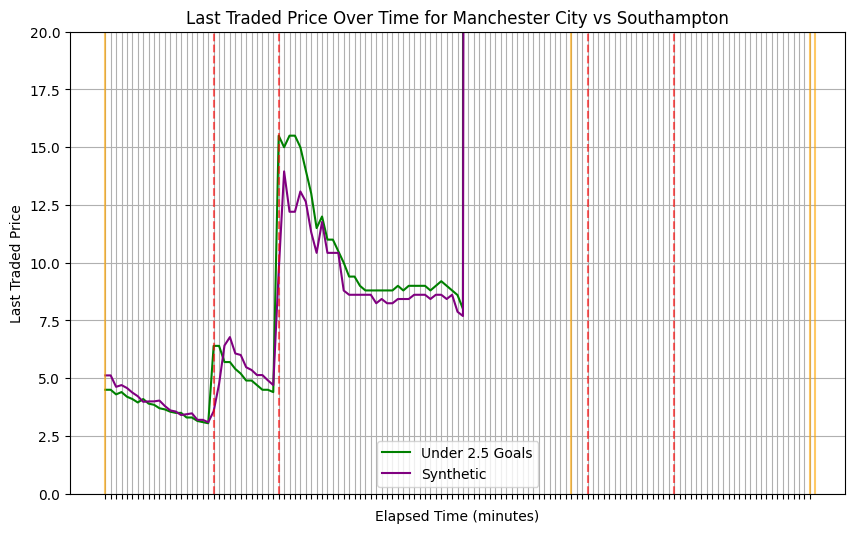

In [24]:
#graph plot function
def plot_odds(new_df,home,away):
    plt.figure(figsize=(10, 6))
    plt.plot('plot label', 'Under 2.5 Odds', data =new_df ,linestyle='-', color='green', label='Under 2.5 Goals')
    #plt.plot('plot label', 'Over 2.5 Odds', data =new_df, linestyle='-', color='blue', label='Over 2.5 Goals')

    plt.plot('plot label', 'Synthetic', data =new_df, linestyle='-', color='purple', label='Synthetic')
    #plt.plot('plot label', '1-1 Odds', data =new_df, linestyle=':' , color='blue', label='1-1 odds')

    plt.xticks(new_df['plot label'],'')
    plt.ylim(bottom = 0, top=20)
    plt.grid()

    goal_times = new_df[new_df['Goal Scored']=='Yes']['plot label']
    for g in goal_times:
        plt.axvline(x=g,color='red',linestyle='--',alpha=0.6)
    
    imp_times = ['0','HT1','46','90']
    for g in imp_times:
        plt.axvline(x=g,color='orange',linestyle='-',alpha=0.6)

    plt.xlabel('Elapsed Time (minutes)')
    plt.ylabel('Last Traded Price')
    plt.title(f'Last Traded Price Over Time for {home} vs {away}')
    plt.legend()
    

plot_odds(match_df('Manchester City', 'Southampton',df),'Manchester City', 'Southampton')

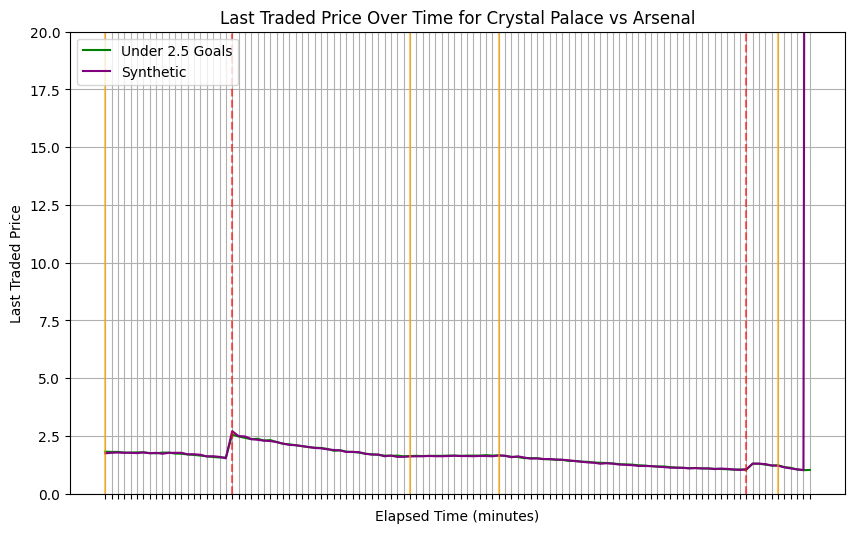

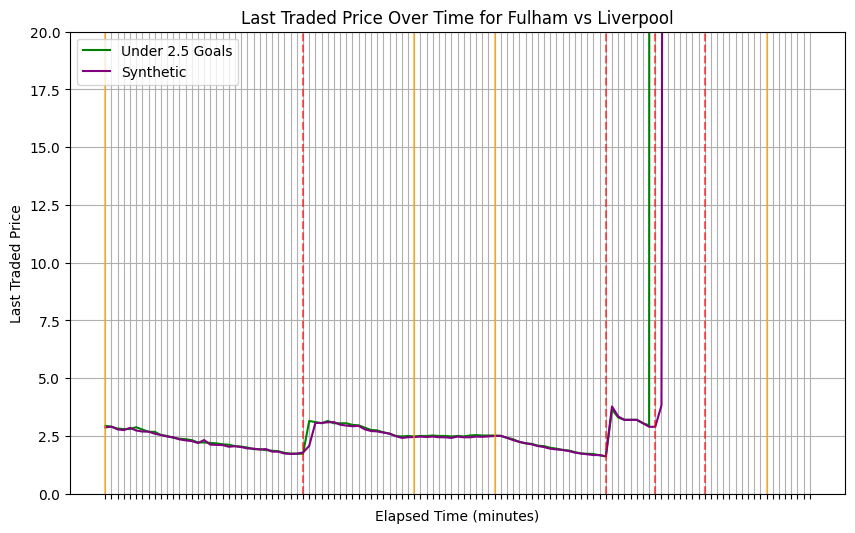

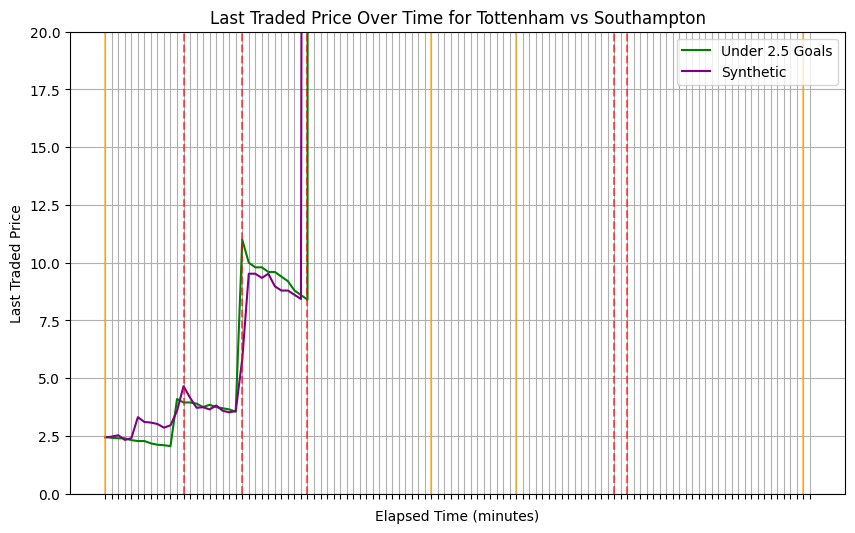

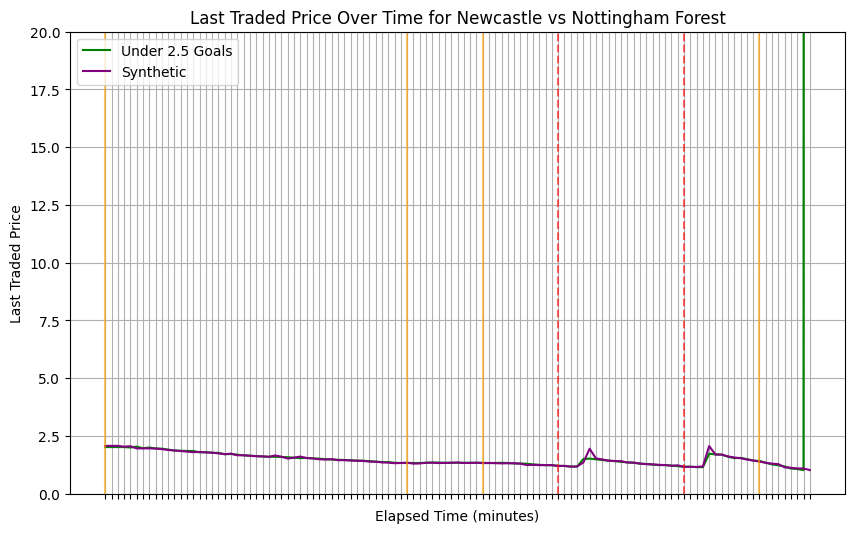

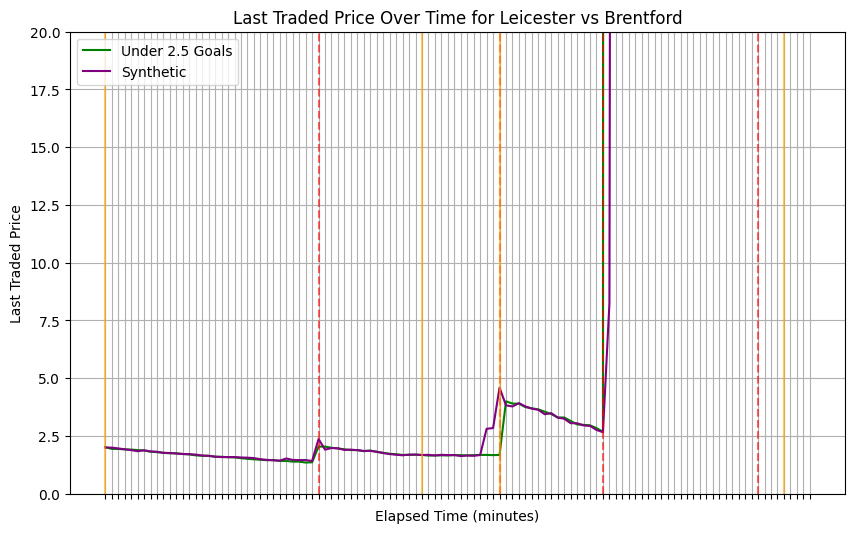

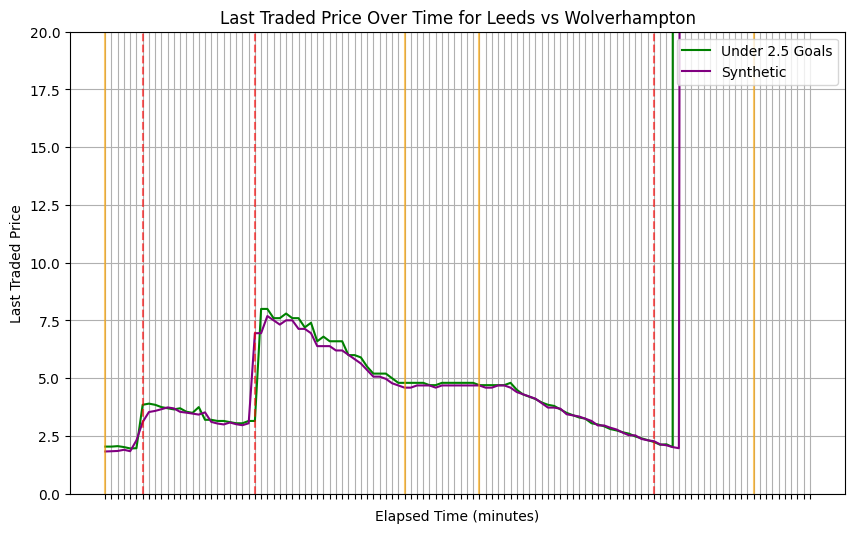

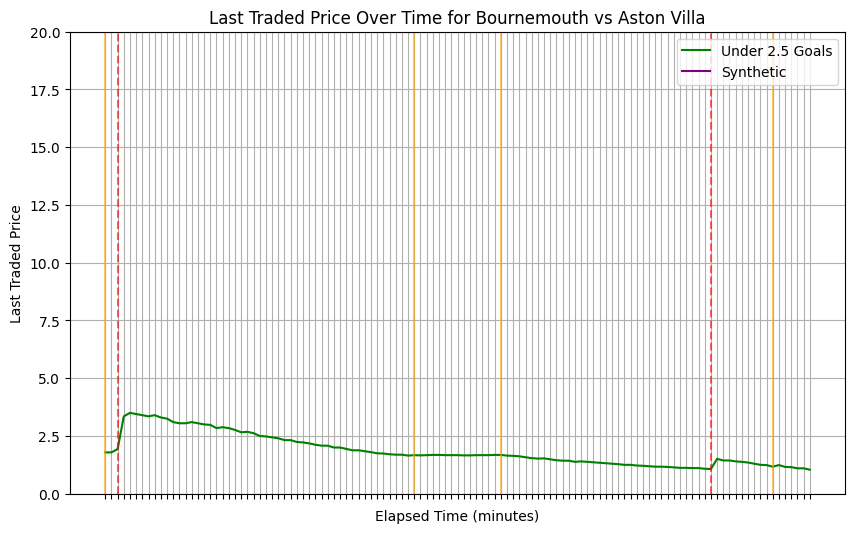

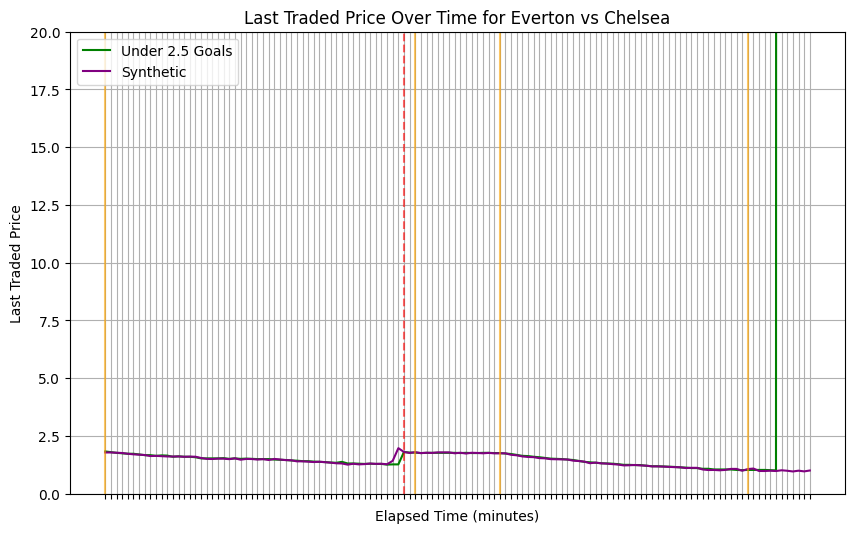

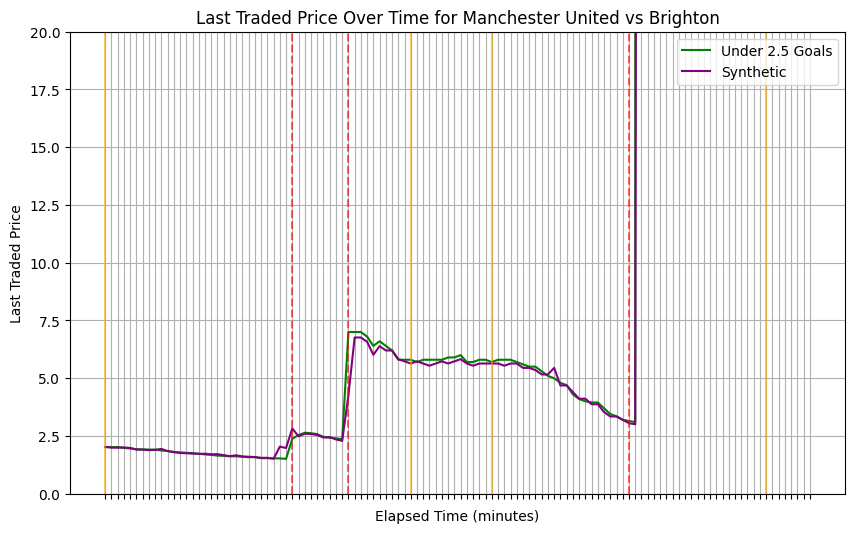

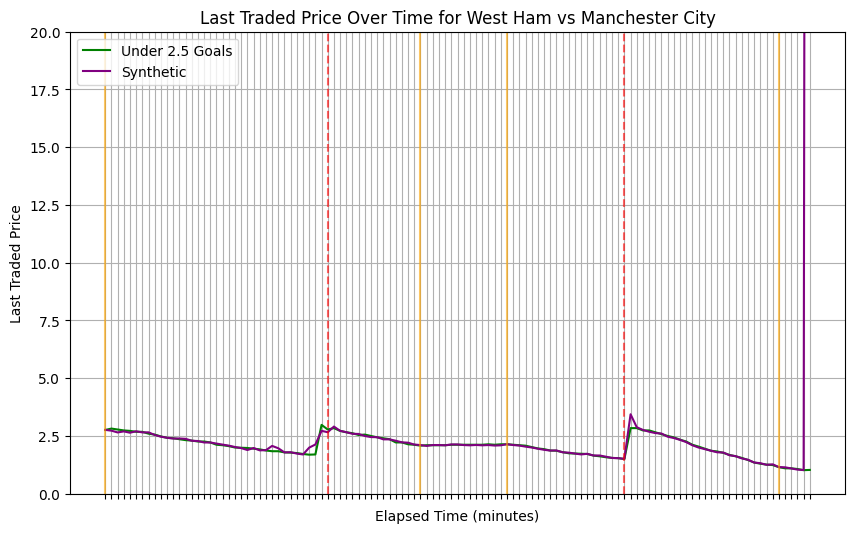

In [26]:
for (home,away) in zipped_matches[:10]:
    plot_odds(match_df(home,away,df),home,away)
plt.show()